In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/src/modeling/atscc/atscc_checkpoints_v10_reg/training_history.csv")

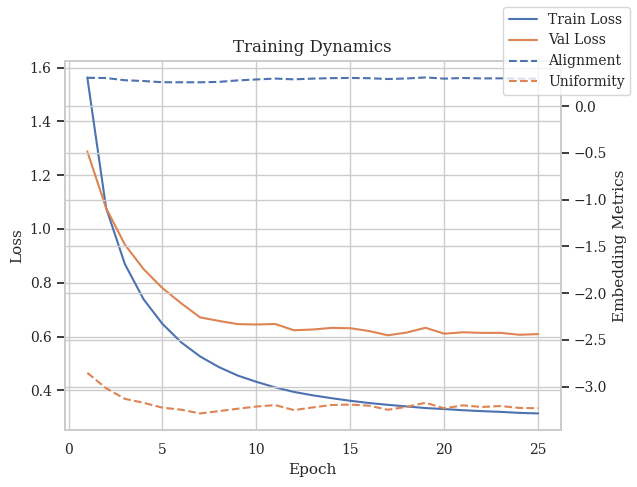

In [28]:
fig, ax1 = plt.subplots()

ax1.plot(epochs, df['train_loss'], label='Train Loss')
ax1.plot(epochs, df['val_loss'], label='Val Loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(epochs, df['alignment'], linestyle='--', label='Alignment')
ax2.plot(epochs, df['uniformity'], linestyle='--', label='Uniformity')
ax2.set_ylabel("Embedding Metrics")

plt.title("Training Dynamics")

fig.legend(loc="upper right")
plt.show()

In [30]:
epochs = 17 

ValueError: x and y must have same first dimension, but have shapes (1,) and (25,)

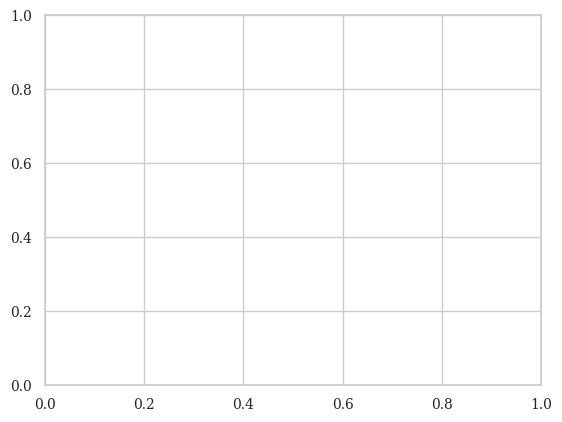

In [36]:
fig, ax1 = plt.subplots()
ax1.plot(epochs, df['train_loss'], label='Train Loss')
ax1.plot(epochs, df['val_loss'], label='Val Loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax2 = ax1.twinx()
ax2.plot(epochs, df['alignment'], linestyle='--', label='Alignment')
ax2.plot(epochs, df['uniformity'], linestyle='--', label='Uniformity')
ax2.set_ylabel("Embedding Metrics")

# Best epoch — val_loss minimu
best_epoch = df['val_loss'].idxmin()
best_val   = df['val_loss'].min()
ax1.axvline(x=epochs[best_epoch], color='gray', lw=1.5, ls=':',
            label=f'Best Epoch={epochs[best_epoch]} (val_loss={best_val:.4f})')
ax1.scatter([epochs[best_epoch]], [best_val], color='gray', s=80, zorder=5)


plt.title("Training Dynamics")
fig.legend(loc="upper right")
plt.show()

In [37]:
df.head()

,epoch,train_loss,val_loss,alignment,uniformity,lr
0,1,1.563708,1.288612,0.303713,-2.852057,0.000002
1,2,1.078618,1.078028,0.301305,-3.016517,0.000003
2,3,0.869532,0.941752,0.277638,-3.130637,0.000005
3,4,0.738074,0.850456,0.268834,-3.173000,0.000007
4,5,0.647032,0.780074,0.256245,-3.224920,0.000007


In [38]:
 
df.columns = df.columns.str.strip()

epochs = df['epoch'].values

best_idx   = df['val_loss'].idxmin()
best_epoch = df.loc[best_idx, 'epoch']
best_val   = df.loc[best_idx, 'val_loss']

print(f'Best epoch    : {best_epoch}')
print(f'Best val_loss : {best_val:.6f}')
print(f'Alignment     : {df.loc[best_idx, "alignment"]:.6f}')
print(f'Uniformity    : {df.loc[best_idx, "uniformity"]:.6f}')
df.head()

Best epoch    : 17
Best val_loss : 0.604500
Alignment     : 0.290621
Uniformity    : -3.247423


,epoch,train_loss,val_loss,alignment,uniformity,lr
0,1,1.563708,1.288612,0.303713,-2.852057,0.000002
1,2,1.078618,1.078028,0.301305,-3.016517,0.000003
2,3,0.869532,0.941752,0.277638,-3.130637,0.000005
3,4,0.738074,0.850456,0.268834,-3.173000,0.000007
4,5,0.647032,0.780074,0.256245,-3.224920,0.000007


In [50]:
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Times New Roman', 'Georgia'],
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.6,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
})

PALETTE = {
    'train':      "#0F56A1",
    'val':        "#E21F1F",
    'alignment':  "#1D6A41",
    'uniformity': '#F4A261',
    'best':       '#6B7280',
    'light':      '#E8F4FD',
}


In [51]:
epochs = df["epoch"].values 

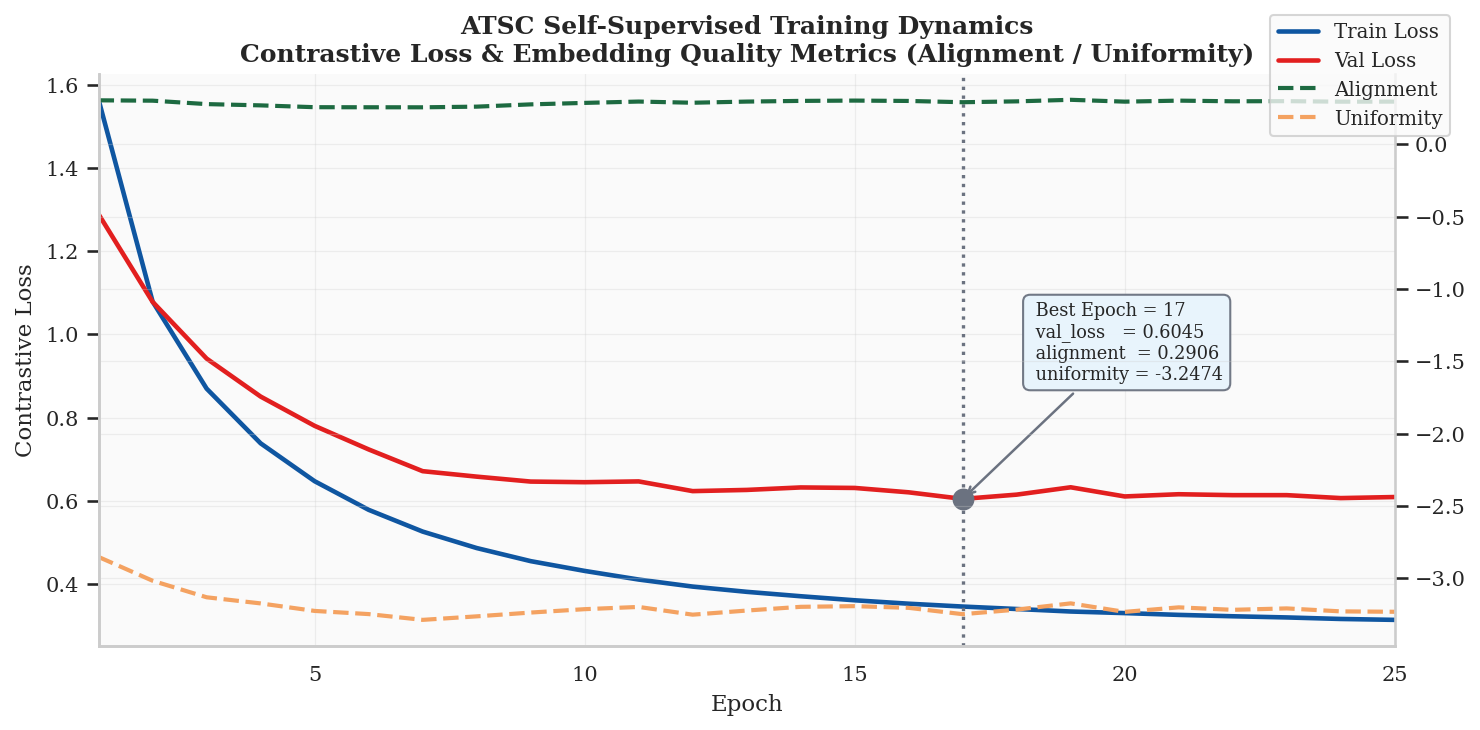

In [57]:
fig, ax1 = plt.subplots(figsize=(10, 5))

l1, = ax1.plot(epochs, df['train_loss'], color=PALETTE['train'],
               lw=2.2, label='Train Loss')
l2, = ax1.plot(epochs, df['val_loss'],   color=PALETTE['val'],
               lw=2.2, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Contrastive Loss')
ax1.set_xlim(epochs[0], epochs[-1])

ax2 = ax1.twinx()
ax2.spines['right'].set_visible(True)
l3, = ax2.plot(epochs, df['alignment'],  color=PALETTE['alignment'],
               lw=2, ls='--', label='Alignment')
l4, = ax2.plot(epochs, df['uniformity'], color=PALETTE['uniformity'],
               lw=2, ls='--', label='Uniformity')


l5 = ax1.axvline(x=best_epoch, color=PALETTE['best'], lw=1.6, ls=':',
                 label=f'Best Epoch = {best_epoch}  (val={best_val:.4f})')
ax1.scatter([best_epoch], [best_val], color=PALETTE['best'], s=90, zorder=6)

ax1.annotate(
    f' Best Epoch = {best_epoch}\n'
    f' val_loss   = {best_val:.4f}\n'
    f' alignment  = {df.loc[best_idx, "alignment"]:.4f}\n'
    f' uniformity = {df.loc[best_idx, "uniformity"]:.4f}',
    xy=(best_epoch, best_val),
    xytext=(best_epoch + max(1, len(epochs) * 0.05),
            best_val + (df['train_loss'].max() - best_val) * 0.3),
    fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', facecolor=PALETTE['light'],
              edgecolor=PALETTE['best'], alpha=0.95),
    arrowprops=dict(arrowstyle='->', color=PALETTE['best'], lw=1.2),
)

fig.legend(handles=[l1, l2, l3, l4],
            bbox_to_anchor=(0.98, 0.98), fontsize=9.5)
plt.title(
    'ATSC Self-Supervised Training Dynamics\n'
    'Contrastive Loss & Embedding Quality Metrics (Alignment / Uniformity)',
    fontsize=12
)
plt.tight_layout()
plt.show()